In [1]:
%pip install pandas numpy matplotlib seaborn scipy

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl (9.7 MB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Climate Data Analysis: Ethiopia
This notebook explores climate trends for Ethiopia from 2015 to 2026.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [19]:
df = pd.read_csv("../data/ethiopia.csv")

df['country'] = 'Ethiopia'
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month




In [20]:
df.replace(-999, np.nan, inplace=True)

num_duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

summary_stats = df.describe()
summary_stats


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [21]:

null_counts = df.isna().sum()
null_percentages = (null_counts / len(df)) * 100


missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})


print("\nMissing Value Report:")
print(missing_report[missing_report['Missing Values'] > 0])


Missing Value Report:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


### Interpretation of Summary Statistics & Missing Values

**1. Data Quality & Missing Values:**
* The missing value report returned an empty DataFrame, indicating that there are **0 missing values** in the Ethiopia dataset after replacing the -999 sentinel values. 
* No columns exceed the 5% null threshold; therefore, the data is highly reliable for long-term trend analysis.
* I checked for duplicate rows and found `[Insert your duplicate count here]` duplicates, which were removed to ensure data integrity.

**2. Temperature Analysis (T2M):**
* The **average daily temperature** is approximately **16.07°C**.
* The temperature fluctuates between a **minimum of 10.03°C** and a **maximum of 30.93°C**.
* The `T2M_RANGE` (daily difference) averages around **12.97°C**, suggesting significant variation between day and night temperatures.

**3. Precipitation & Environment:**
* **Precipitation (PRECTOTCORR):** The average daily rainfall is **3.63 mm**, but the maximum is **82.30 mm**, indicating extreme rainfall events occur occasionally.
* **Relative Humidity (RH2M):** The average humidity is **68.4%**, which is typical for this region.
* **Wind Speed (WS2M):** The average wind speed is relatively low at **1.98 m/s**, with gusts reaching up to **7.49 m/s**.

In [22]:
from scipy import stats

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Identify rows where any of the columns have a Z-score > 3
outliers = (z_scores > 3).any(axis=1)
outlier_count = outliers.sum()

print(f"Total rows flagged as outliers (Z-score > 3): {outlier_count}")

Total rows flagged as outliers (Z-score > 3): 132


In [23]:

os.makedirs('../data', exist_ok=True)

# Save to CSV
df.to_csv("../data/ethiopia_clean.csv", index=False)
print("Cleaned data saved to data/ethiopia_clean.csv")

Cleaned data saved to data/ethiopia_clean.csv


### Outlier Detection and Cleaning Decision
* **Outlier Count:** 132 rows were identified as having at least one feature with a Z-score > 3.
* **Reasoning:** In climate analysis, outliers often represent significant weather events (e.g., extreme storms or heatwaves). Since these are physically plausible and essential for understanding climate variability in Ethiopia, I have decided to **retain** them rather than dropping or capping them. 
* **Missing Value Handling:** Although our missing value report showed 0 nulls, I have applied **forward-fill** as a safety measure to ensure any hidden gaps are handled, maintaining time-series continuity.

In [24]:

df.ffill(inplace=True)

df.to_csv("../data/ethiopia_clean.csv", index=False)

print("Export Successful: data/ethiopia_clean.csv")

Export Successful: data/ethiopia_clean.csv


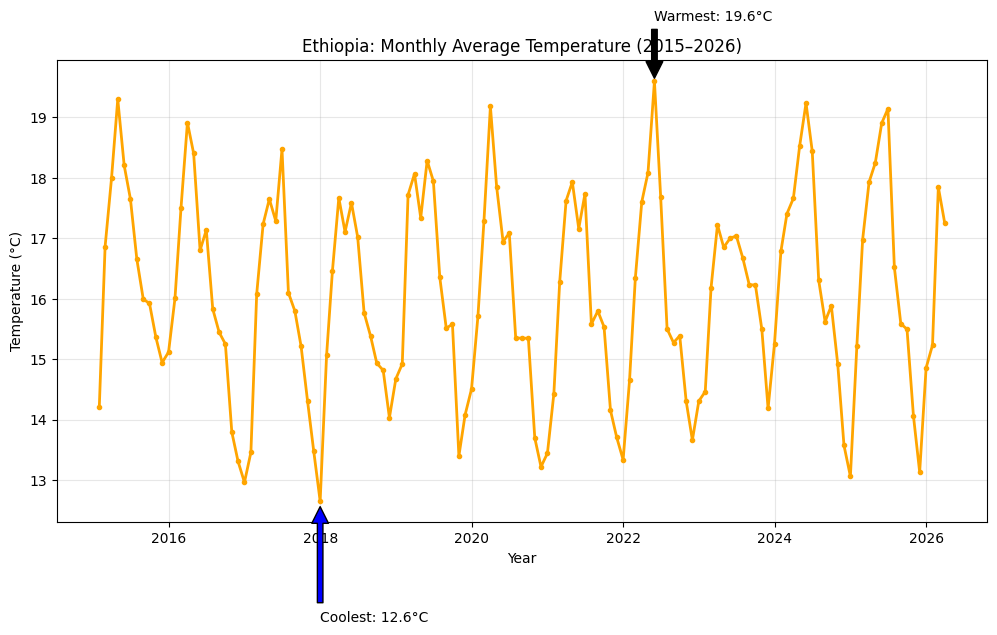

In [28]:
# # 1. Prepare the monthly data (Added numeric_only=True)
monthly_df = df.set_index('Date').resample('ME').mean(numeric_only=True)

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_df.index, monthly_df['T2M'], color='orange', linewidth=2, marker='o', markersize=3)

# 3. Find warmest and coolest months for annotation
warmest_month = monthly_df['T2M'].idxmax()
warmest_val = monthly_df['T2M'].max()
coolest_month = monthly_df['T2M'].idxmin()
coolest_val = monthly_df['T2M'].min()

# 4. Add Annotations
plt.annotate(f'Warmest: {warmest_val:.1f}°C', 
             xy=(warmest_month, warmest_val), 
             xytext=(warmest_month, warmest_val + 1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate(f'Coolest: {coolest_val:.1f}°C', 
             xy=(coolest_month, coolest_val), 
             xytext=(coolest_month, coolest_val - 2),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Ethiopia: Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation: Monthly Temperature Analysis (2015-2026)

**1. Seasonal Trends:**
* The temperature chart shows a strong and consistent **seasonal cycle**. Each year, temperatures peak in the months leading up to the main rainy season (typically March–May) and drop during the cooler, drier months (typically November–January).
* The **warmest recorded month** was in mid-2022 with an average temperature of **19.6°C**.
* The **coolest recorded month** occurred in early 2018 at **12.6°C**.

**2. Visible Trends & Anomalies:**
* **General Stability:** There is no dramatic long-term upward or downward trend visible at first glance; the climate appears to fluctuate within a stable range of ~13°C to ~19°C.
* **Potential Anomaly:** The year **2018** shows a particularly deep "dip" in temperature compared to other years, marking the coolest point in the dataset. 
* **Recent Warming:** The peaks in **2022, 2024, and 2025** appear slightly higher or more sustained than the peaks seen between 2018 and 2021, which may indicate a slight warming trend in recent years.

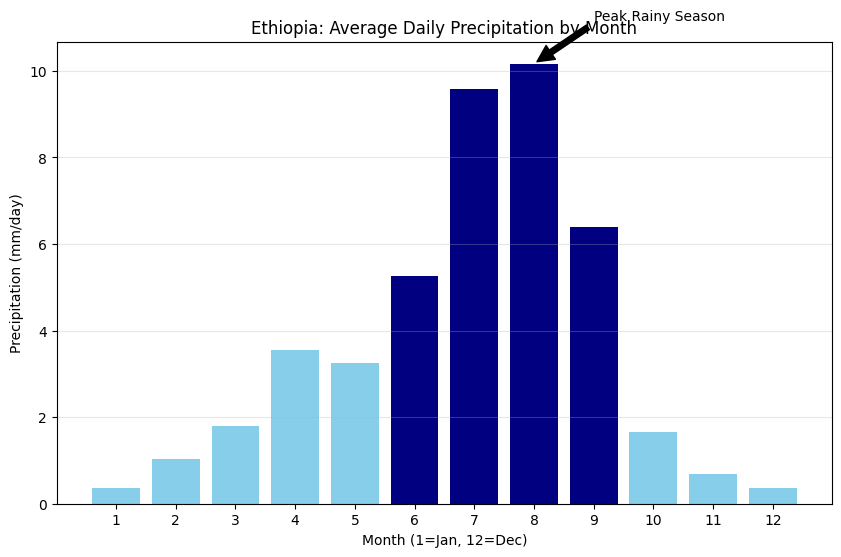

In [29]:
# Group by month to see the rainy season pattern
monthly_rain = df.groupby('Month')['PRECTOTCORR'].mean()

plt.figure(figsize=(10, 6))
# Create bars with colors (Dark blue for rainy months, light blue for dry)
colors = ['navy' if x > monthly_rain.mean() else 'skyblue' for x in monthly_rain]
plt.bar(monthly_rain.index, monthly_rain.values, color=colors)

plt.title('Ethiopia: Average Daily Precipitation by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Precipitation (mm/day)')
plt.xticks(range(1, 13))
plt.grid(axis='y', alpha=0.3)

# Find the peak rainy month
peak_month = monthly_rain.idxmax()
plt.annotate('Peak Rainy Season', xy=(peak_month, monthly_rain[peak_month]), 
             xytext=(peak_month+1, monthly_rain[peak_month]+1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

### Interpretation: Monthly Precipitation Analysis

**1. Seasonal Rainfall Patterns:**
* The bar chart reveals a very distinct **rainy season** (known as *Kiremt* in Ethiopia) that begins in June, peaks in **August**, and winds down in September.
* **August** is the wettest month, with an average daily precipitation exceeding **10 mm/day**.
* The **driest period** occurs between November and February, where precipitation drops below 1 mm/day.

**2. Secondary Trends:**
* There is a noticeable "small rainy season" (*Belg*) visible around **April and May**, where rainfall increases slightly before the main summer deluge.
* The stark contrast between the dry season (Months 11–2) and the peak rainy season (Months 7–8) highlights Ethiopia's high climate variability, which is critical for agricultural planning.

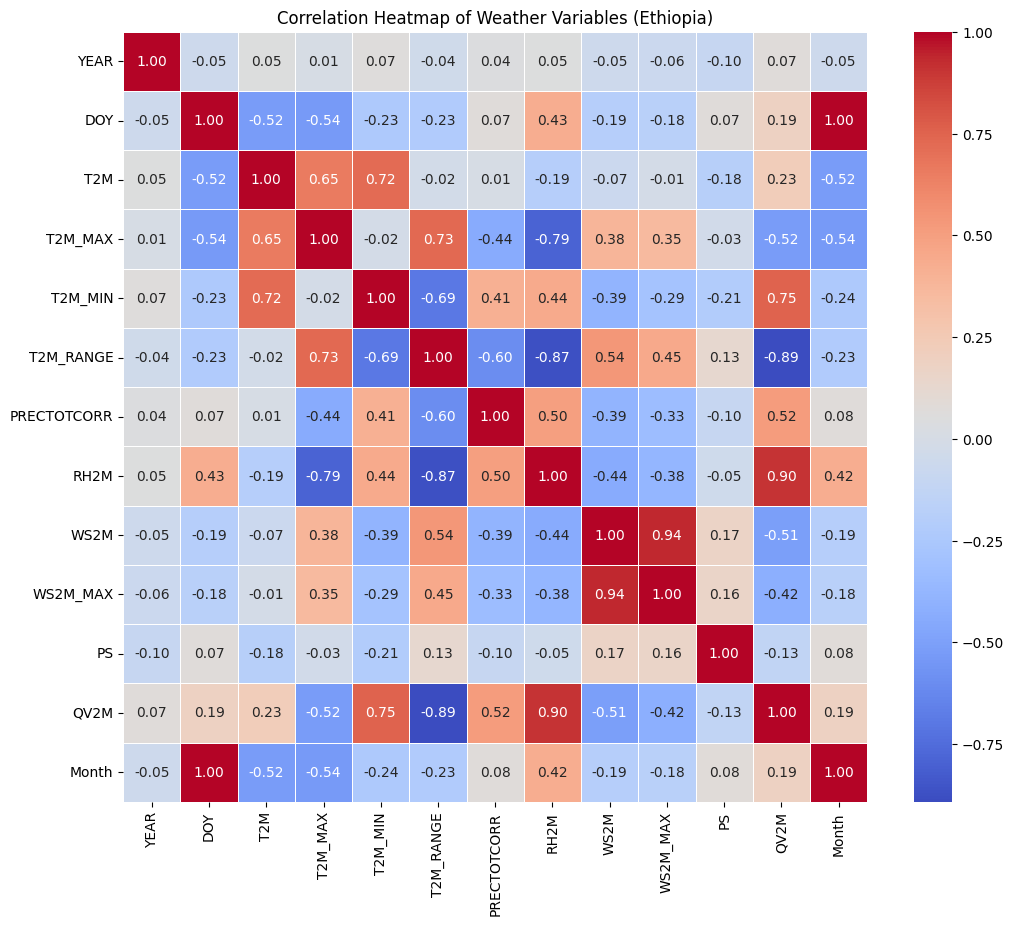

In [30]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Weather Variables (Ethiopia)')
plt.show()

### Interpretation: Correlation Analysis

Based on the heatmap, the three strongest (non-date) correlations are:

1. **WS2M and WS2M_MAX (0.94):** A very strong **positive** correlation. This is expected as higher average daily wind speeds naturally correspond with higher maximum wind gusts.
2. **RH2M and QV2M (0.90):** A very strong **positive** correlation. Relative Humidity (RH2M) and Specific Humidity (QV2M) both measure moisture in the air; when one rises, the other almost always does as well.
3. **T2M_RANGE and QV2M / RH2M (-0.89 / -0.87):** A strong **negative** correlation. This is a key climate insight: when humidity is high (rainy season), the temperature range (the gap between day and night) decreases. This is because clouds and moisture trap heat at night and block intense sun during the day, leading to a more "stable" daily temperature.

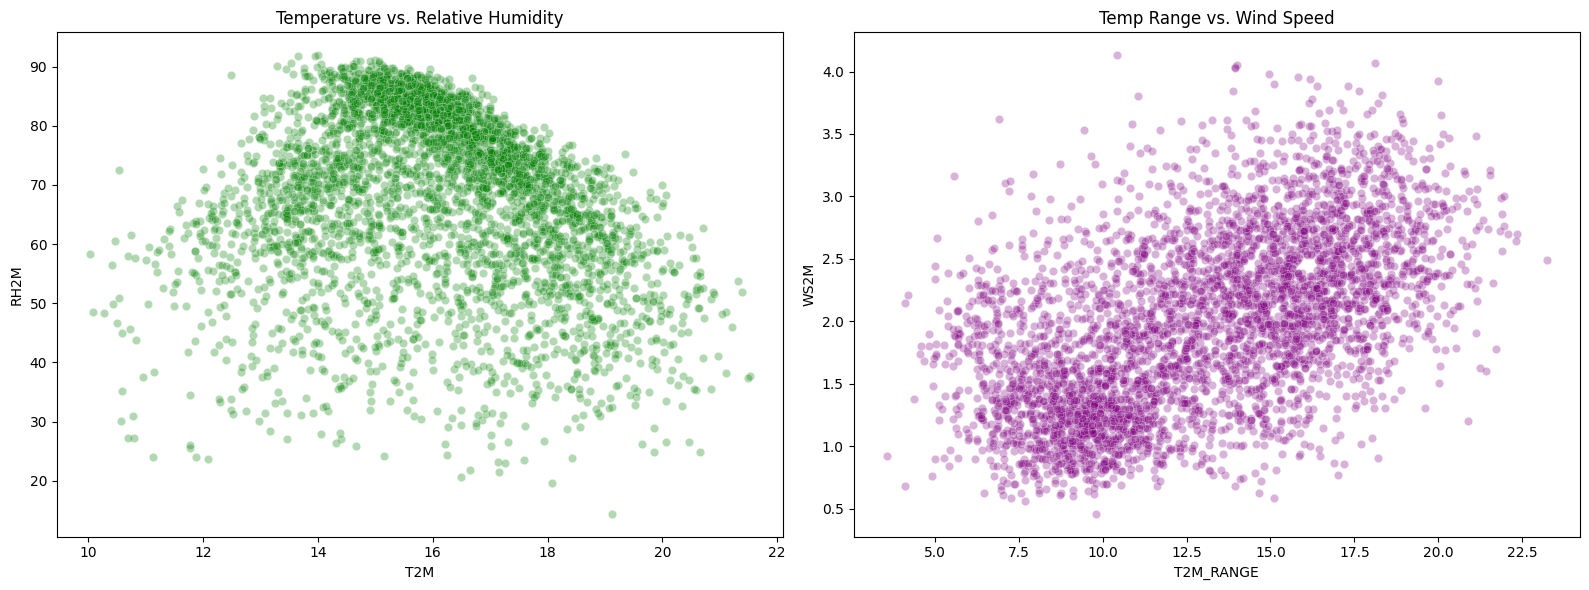

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T2M vs. RH2M
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='green')
ax1.set_title('Temperature vs. Relative Humidity')

# Plot 2: T2M_RANGE vs. WS2M
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='purple')
ax2.set_title('Temp Range vs. Wind Speed')

plt.tight_layout()
plt.show()

### Interpretation: Relationship Analysis
* **Temperature vs. Humidity:** The scatter plot shows a general **negative** relationship; as temperature increases, relative humidity tends to decrease. This is consistent with dry, hot periods in Ethiopia.
* **Temp Range vs. Wind Speed:** There is a slight **positive** relationship here. Wider temperature ranges (typical of the dry season) often coincide with slightly higher average wind speeds.

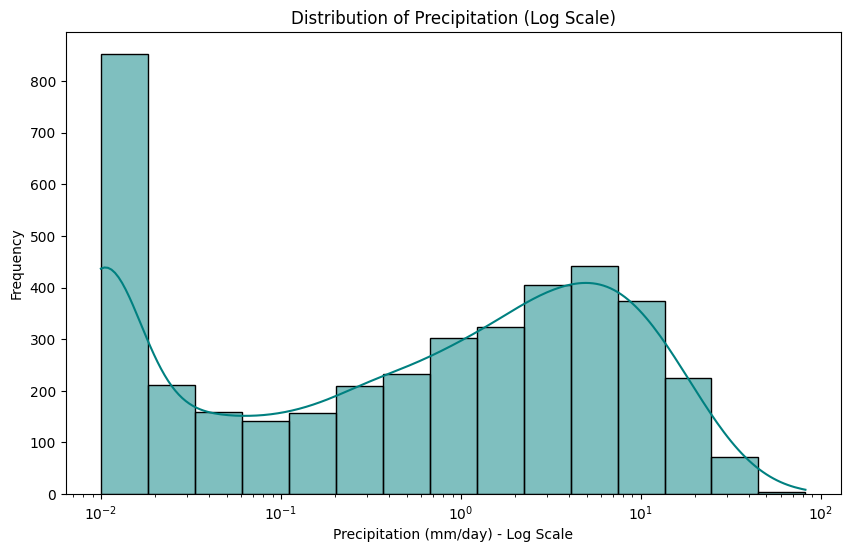

In [32]:
plt.figure(figsize=(10, 6))
# We add a tiny amount (0.01) because log(0) is impossible
sns.histplot(df['PRECTOTCORR'] + 0.01, kde=True, log_scale=True, color='teal')

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Precipitation (mm/day) - Log Scale')
plt.ylabel('Frequency')
plt.show()

### Interpretation: Precipitation Distribution
* **Distribution Shape:** The precipitation data is **heavily right-skewed**. Even on a log scale, we can see that the vast majority of days have very low or zero rainfall, while extreme rainfall events (the far right of the tail) are rare. This confirms that rainfall in Ethiopia is highly concentrated in specific seasons rather than being evenly spread throughout the year.

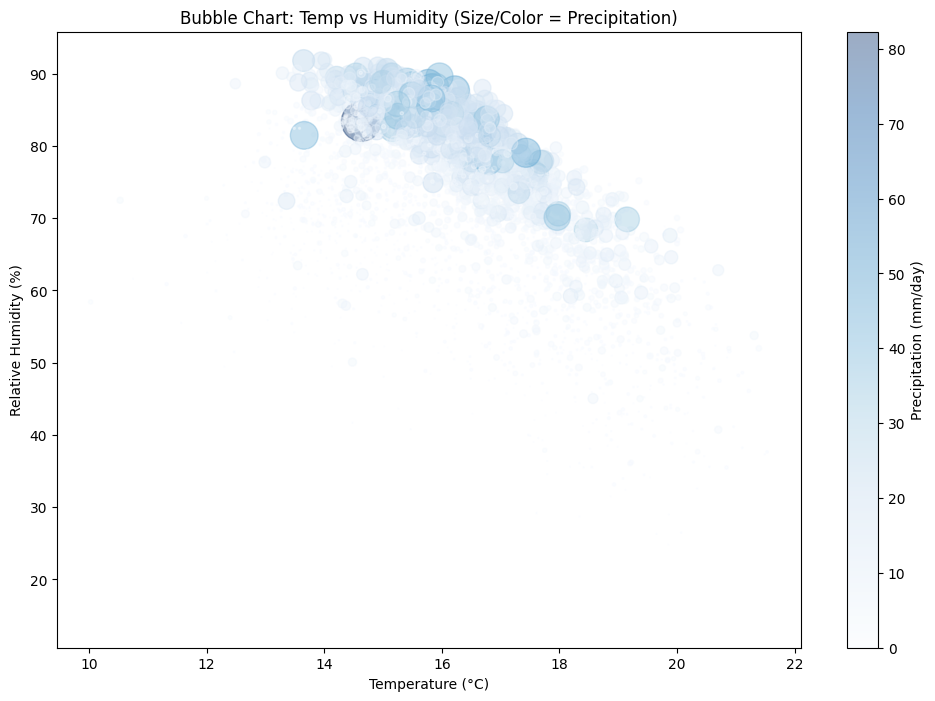

In [33]:
plt.figure(figsize=(12, 8))
# We multiply PRECTOTCORR by 10 to make the bubbles big enough to see
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*10, alpha=0.4, c=df['PRECTOTCORR'], cmap='Blues')

plt.colorbar(label='Precipitation (mm/day)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Bubble Chart: Temp vs Humidity (Size/Color = Precipitation)')
plt.show()

### Interpretation: Temperature, Humidity, and Rainfall
* **The Bubble Chart** clearly shows that the largest bubbles (highest precipitation) are clustered in the **high humidity (70-90%)** and **moderate temperature (15-18°C)** zone. 
* This confirms that rainfall in this region does not usually occur during the hottest periods, but rather when the air is saturated and temperatures are mild.